In [1]:
import os
import glob
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pickle
import networkx as nx

plt.style.use("seaborn-v0_8")

In [2]:
DATA_DIR = "../data/rsfMRI"   

print("Files found:")
print(glob.glob(os.path.join(DATA_DIR, "*.pkl")))


Files found:
['../data/rsfMRI\\002GNV_TC_Schaefer.pkl', '../data/rsfMRI\\003GNV_TC_Schaefer.pkl', '../data/rsfMRI\\004GNV_TC_Schaefer.pkl', '../data/rsfMRI\\rsfMRI_utils.pkl']


In [3]:
data_all = {}

files = glob.glob(os.path.join(DATA_DIR, "*_TC_Schaefer.pkl"))

for file in files:
    subj_id = os.path.basename(file).split("_")[0]
    with open(file, "rb") as f:
        data_all[subj_id] = pickle.load(f)

print(f"Loaded {len(data_all)} subjects")


Loaded 3 subjects


In [4]:
# Look at first subject
first_subj = list(data_all.keys())[0]
print("Subject ID:", first_subj)

print("\nSessions available:")
print(data_all[first_subj].keys())


Subject ID: 002GNV

Sessions available:
dict_keys(['V01_100', 'V01_200', 'V01_400', 'V01_800', 'V02_100', 'V02_200', 'V02_400', 'V02_800', 'V04_100', 'V04_200', 'V04_400', 'V04_800', 'V05_100', 'V05_200', 'V05_400', 'V05_800', 'V06_100', 'V06_200', 'V06_400', 'V06_800', 'V07_100', 'V07_200', 'V07_400', 'V07_800', 'V08_100', 'V08_200', 'V08_400', 'V08_800', 'V09_100', 'V09_200', 'V09_400', 'V09_800', 'V10_100', 'V10_200', 'V10_400', 'V10_800', 'V11_100', 'V11_200', 'V11_400', 'V11_800', 'V12_100', 'V12_200', 'V12_400', 'V12_800', 'V13_100', 'V13_200', 'V13_400', 'V13_800', 'V14_100', 'V14_200', 'V14_400', 'V14_800', 'V15_100', 'V15_200', 'V15_400', 'V15_800'])


In [5]:
example_session = list(data_all[first_subj].keys())[1]

ts = data_all[first_subj][example_session]

print("Shape of time series matrix:")
print(ts.shape)

fc = np.corrcoef(ts, rowvar=False)  # correlate columns (regions)

Shape of time series matrix:
(320, 219)


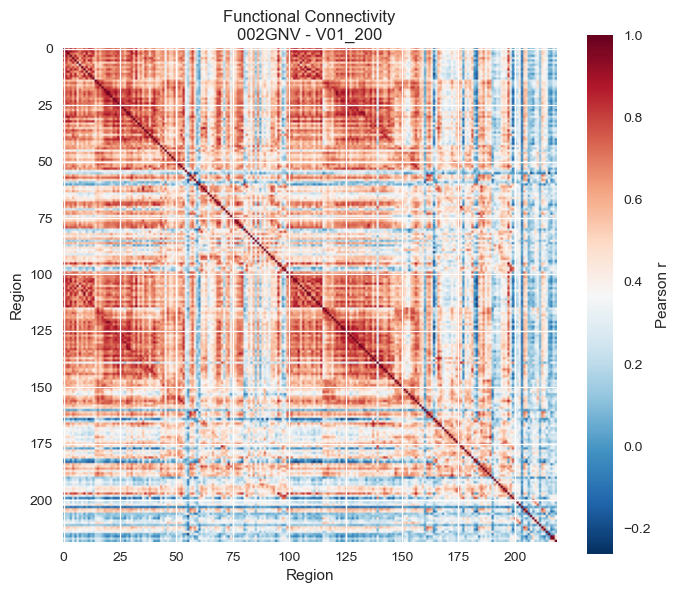

In [6]:
plt.figure(figsize=(7, 6))

plt.imshow(fc,
           cmap="RdBu_r")

plt.colorbar(label="Pearson r")
plt.title(f"Functional Connectivity\n{first_subj} - {example_session}")
plt.xlabel("Region")
plt.ylabel("Region")

plt.tight_layout()
plt.show()


In [7]:
with open("../data/rsfMRI/rsfMRI_utils.pkl", "rb") as f:
    rsfMRI_utils = pickle.load(f)

print(rsfMRI_utils.keys())


dict_keys(['AudROI', 'AudROIoverlap', 'FDindices', 'PCidx', 'yeo7'])


In [8]:
yeo_info = rsfMRI_utils["yeo7"][200]

yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()
print("Yeo labels length:", len(yeo_rois))
print("Unique network ids:", np.unique(yeo_rois))

Yeo labels length: 219
Unique network ids: [1 2 3 4 5 6 7 8 9]


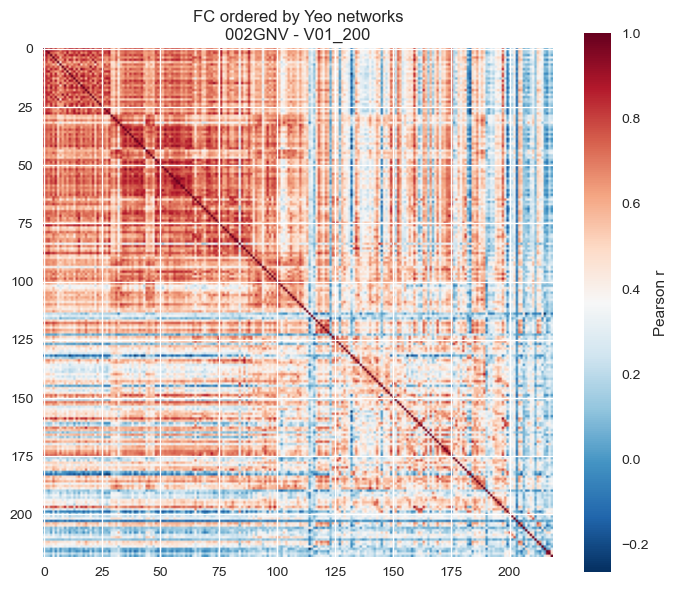

In [9]:
order = np.argsort(yeo_rois)

fc_sorted = fc[np.ix_(order, order)]
yeo_sorted = yeo_rois[order]

plt.figure(figsize=(7, 6))
plt.imshow(fc_sorted, cmap="RdBu_r")



plt.colorbar(label="Pearson r")
plt.title(f"FC ordered by Yeo networks\n{first_subj} - {example_session}")
plt.tight_layout()
plt.show()


In [10]:
cortical_mask = yeo_rois <= 7   # keeps networks 1..7
print("Number of cortical ROIs:", cortical_mask.sum())

Number of cortical ROIs: 200


In [11]:
fc_cortical = fc[np.ix_(cortical_mask, cortical_mask)]
yeo_cortical = yeo_rois[cortical_mask]

print("Cortical FC shape:", fc_cortical.shape)

Cortical FC shape: (200, 200)


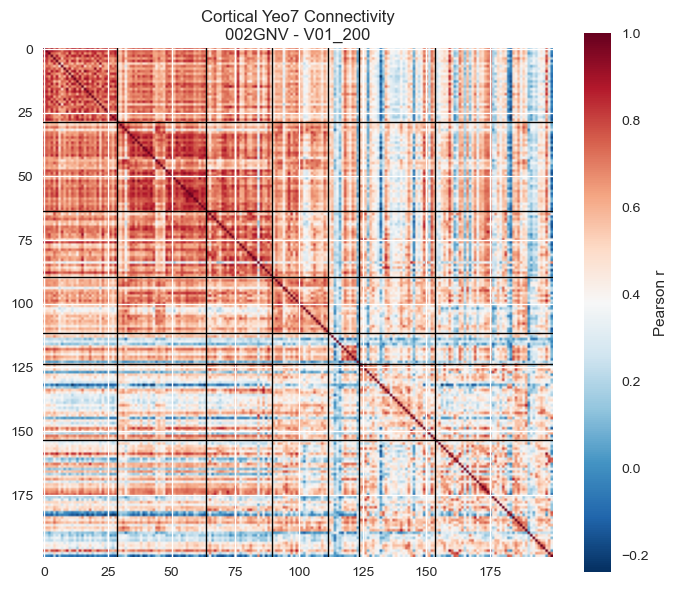

In [12]:
order = np.argsort(yeo_cortical)

fc_sorted = fc_cortical[np.ix_(order, order)]
yeo_sorted = yeo_cortical[order]

plt.figure(figsize=(7, 6))
plt.imshow(fc_sorted, cmap="RdBu_r")

# draw boundaries between networks
change = np.where(np.diff(yeo_sorted) != 0)[0] + 1
for b in change:
    plt.axhline(b - 0.5, color="black", linewidth=1)
    plt.axvline(b - 0.5, color="black", linewidth=1)

plt.colorbar(label="Pearson r")
plt.title(f"Cortical Yeo7 Connectivity\n{first_subj} - {example_session}")
plt.tight_layout()
plt.show()


In [13]:
# --- pick your subject/session ---
subj = first_subj          # or "008GNV"
sess = 'V01_200'         

# --- load labels (1..9) ---
yeo_info = rsfMRI_utils["yeo7"][200]
yeo_rois = np.array(yeo_info["yeoROIs"]).astype(int).ravel()

# --- compute FC ---
ts = data_all[subj][sess]                   # shape (T, 219)
fc = np.corrcoef(ts, rowvar=False)          # shape (219, 219)
np.fill_diagonal(fc, np.nan)                # ignore diagonal in averages

assert fc.shape[0] == len(yeo_rois), (fc.shape, len(yeo_rois))

# --- cortical-only mask: keep networks 1..7, drop 8 & 9 (subcortical) ---
cortical_mask = yeo_rois <= 7

fc_cx = fc[np.ix_(cortical_mask, cortical_mask)]
yeo_cx = yeo_rois[cortical_mask]

print("Cortical FC shape:", fc_cx.shape)
print("Unique cortical networks:", np.unique(yeo_cx))


Cortical FC shape: (200, 200)
Unique cortical networks: [1 2 3 4 5 6 7]


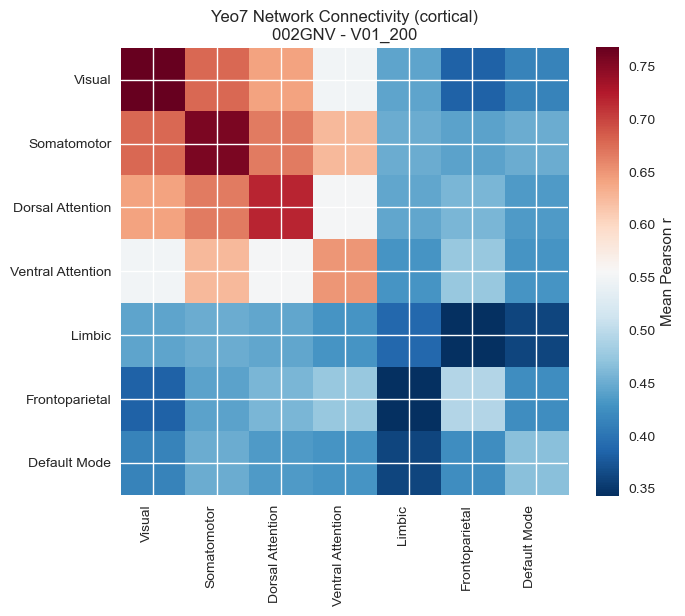

In [14]:
# Fisher transform first
fc_z = np.arctanh(fc_cx)

# Make sure diagonal is NaN
np.fill_diagonal(fc_z, np.nan)

nets = np.arange(1, 8)
netmat = np.full((7, 7), np.nan)

for i, ni in enumerate(nets):
    idx_i = np.where(yeo_cx == ni)[0]
    
    for j, nj in enumerate(nets):
        idx_j = np.where(yeo_cx == nj)[0]
        
        block = fc_z[np.ix_(idx_i, idx_j)]
        
        # If within-network, remove diagonal entries
        if i == j:
            block = block[~np.eye(len(idx_i), dtype=bool)]
        
        netmat[i, j] = np.nanmean(block)

# Convert back to r for interpretability
netmat_r = np.tanh(netmat)

# Yeo7 canonical names
network_names = [
    "Visual",
    "Somatomotor",
    "Dorsal Attention",
    "Ventral Attention",
    "Limbic",
    "Frontoparietal",
    "Default Mode"
]

plt.figure(figsize=(7, 6))
plt.imshow(netmat_r, cmap="RdBu_r")
plt.colorbar(label="Mean Pearson r")

plt.xticks(range(7), network_names, rotation=90, ha="right")
plt.yticks(range(7), network_names)

plt.title(f"Yeo7 Network Connectivity (cortical)\n{subj} - {sess}")
plt.tight_layout()
plt.show()


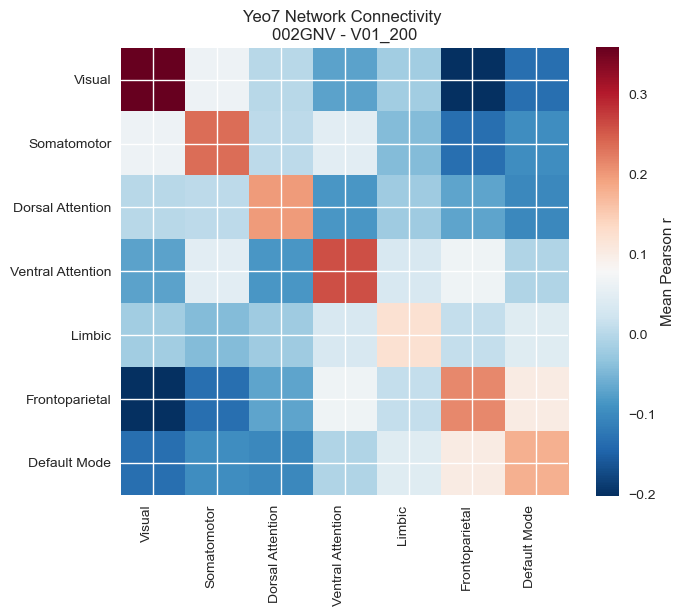

In [15]:
ts = data_all[subj][sess].copy()

# regress out global signal (simple linear regression)
gs = np.nanmean(ts, axis=1)
gs = (gs - gs.mean()) / gs.std()

beta = (gs @ ts) / (gs @ gs)         # shape (n_rois,)
ts_gsr = ts - np.outer(gs, beta)

fc_gsr = np.corrcoef(ts_gsr, rowvar=False)
np.fill_diagonal(fc_gsr, np.nan)

# apply the same cortical mask you used before
fc_gsr_cx = fc_gsr[np.ix_(cortical_mask, cortical_mask)]
edges_gsr = fc_gsr_cx[np.triu_indices_from(fc_gsr_cx, k=1)]

# Fisher transform first
fc_z = np.arctanh(fc_gsr_cx)

# Make sure diagonal is NaN
np.fill_diagonal(fc_z, np.nan)

nets = np.arange(1, 8)
netmat = np.full((7, 7), np.nan)

for i, ni in enumerate(nets):
    idx_i = np.where(yeo_cx == ni)[0]
    
    for j, nj in enumerate(nets):
        idx_j = np.where(yeo_cx == nj)[0]
        
        block = fc_z[np.ix_(idx_i, idx_j)]
        
        # If within-network, remove diagonal entries
        if i == j:
            block = block[~np.eye(len(idx_i), dtype=bool)]
        
        netmat[i, j] = np.nanmean(block)

# Convert back to r for interpretability
netmat_r = np.tanh(netmat)

plt.figure(figsize=(7, 6))
plt.imshow(netmat_r, cmap="RdBu_r")
plt.colorbar(label="Mean Pearson r")

plt.xticks(range(7), network_names, rotation=90, ha="right")
plt.yticks(range(7), network_names)

plt.title(f"Yeo7 Network Connectivity \n{subj} - {sess}")
plt.tight_layout()
plt.show()



In [16]:
def compute_network_matrix(ts, yeo_rois, cortical_mask):
    fc = np.corrcoef(ts, rowvar=False)
    np.fill_diagonal(fc, np.nan)
    
    fc_cx = fc[np.ix_(cortical_mask, cortical_mask)]
    yeo_cx = yeo_rois[cortical_mask]
    
    # Fisher transform
    fc_z = np.arctanh(fc_cx)
    
    nets = np.arange(1, 8)
    netmat = np.full((7, 7), np.nan)
    
    for i, ni in enumerate(nets):
        idx_i = np.where(yeo_cx == ni)[0]
        
        for j, nj in enumerate(nets):
            idx_j = np.where(yeo_cx == nj)[0]
            
            block = fc_z[np.ix_(idx_i, idx_j)]
            
            if i == j:
                tri = np.triu_indices(len(idx_i), k=1)
                block = block[tri]
            
            netmat[i, j] = np.nanmean(block)
    
    return np.tanh(netmat)  # back to r



In [17]:
limbic_idx = 4  # Visual=0, Somatomotor=1, ..., Limbic=4

longitudinal_data = {}

for subj in data_all.keys():
    limbic_values = []
    
    # sort sessions properly (V01_200 ... V15_200)
    sessions = sorted([s for s in data_all[subj].keys() if "_200" in s])
    
    for sess in sessions:
        ts = data_all[subj][sess]
        
        netmat = compute_network_matrix(ts, yeo_rois, cortical_mask)
        limbic_values.append(netmat[limbic_idx, limbic_idx])
    
    longitudinal_data[subj] = limbic_values


c:\Users\tesni\miniconda3\envs\TinProject\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\tesni\miniconda3\envs\TinProject\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


In [18]:
for subj, vals in longitudinal_data.items():
    print(subj, len(vals))

002GNV 14
003GNV 14
004GNV 15


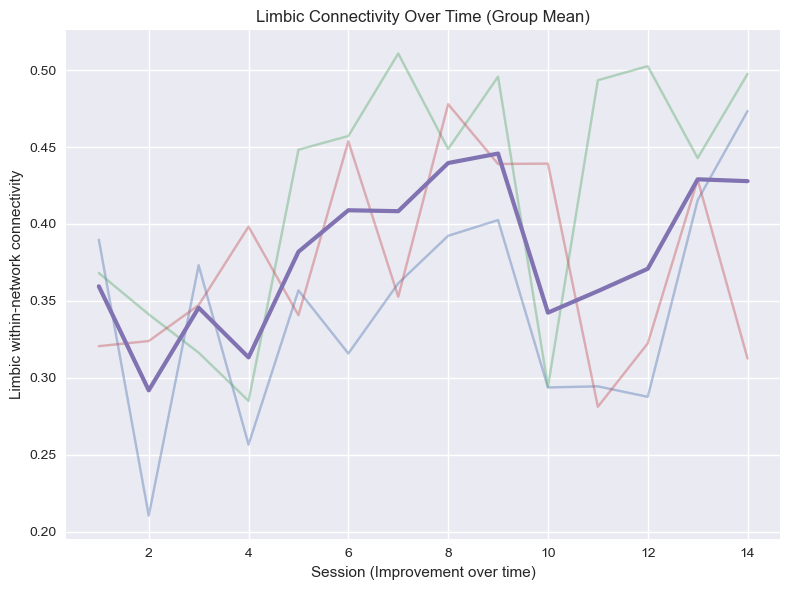

In [19]:
# Make all subjects the same length (use the first 14 sessions)
min_len = min(len(v) for v in longitudinal_data.values())  # will be 14
longitudinal_data_fixed = {k: v[:min_len] for k, v in longitudinal_data.items()}

all_values = np.array(list(longitudinal_data_fixed.values()))
mean_traj = np.nanmean(all_values, axis=0)

plt.figure(figsize=(8,6))

# individual
for subj, values in longitudinal_data_fixed.items():
    plt.plot(range(1, len(values)+1), values, alpha=0.4)

# group mean
plt.plot(range(1, len(mean_traj)+1), mean_traj, linewidth=3)

plt.xlabel("Session (Improvement over time)")
plt.ylabel("Limbic within-network connectivity")
plt.title("Limbic Connectivity Over Time (Group Mean)")
plt.tight_layout()
plt.show()

plt.show()


In [20]:
subjs = sorted(data_all.keys())
sessions_14 = [f"V{str(k).zfill(2)}_200" for k in range(1, 15)]

n_subj = len(subjs)
n_sess = len(sessions_14)
n_net = 7

ALL = np.full((n_subj, n_sess, n_net, n_net), np.nan)

for i, subj in enumerate(subjs):
    for j, sess in enumerate(sessions_14):
        if sess in data_all[subj]:
            ts = data_all[subj][sess]
            netmat = compute_network_matrix(ts, yeo_rois, cortical_mask)
            ALL[i, j] = netmat

print("Shape:", ALL.shape)


Shape: (3, 14, 7, 7)


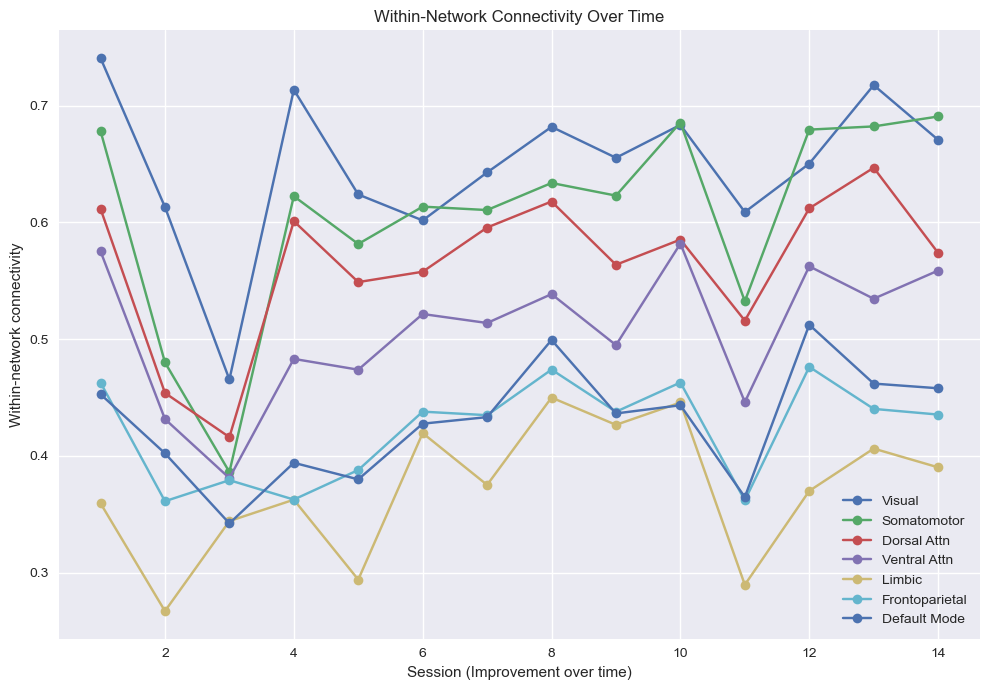

In [21]:
network_names = [
    "Visual",
    "Somatomotor",
    "Dorsal Attn",
    "Ventral Attn",
    "Limbic",
    "Frontoparietal",
    "Default Mode"
]

x = np.arange(1, 15)

plt.figure(figsize=(10,7))

for net in range(7):
    within = ALL[:, :, net, net]          # subjects × sessions
    mean_traj = np.nanmean(within, axis=0)
    plt.plot(x, mean_traj, marker="o", label=network_names[net])

plt.xlabel("Session (Improvement over time)")
plt.ylabel("Within-network connectivity")
plt.title("Within-Network Connectivity Over Time")
plt.legend()
plt.tight_layout()
plt.show()


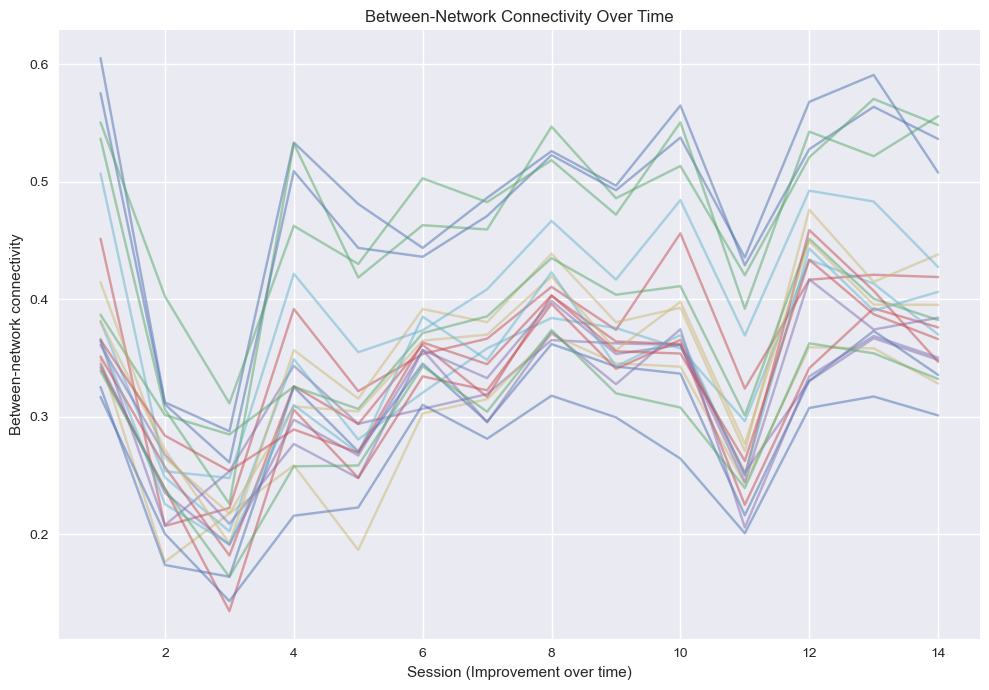

In [22]:
plt.figure(figsize=(10,7))

for i in range(7):
    for j in range(i+1, 7):  # only unique pairs
        between = ALL[:, :, i, j]      # subjects × sessions
        mean_traj = np.nanmean(between, axis=0)
        
        label = f"{network_names[i]}–{network_names[j]}"
        plt.plot(x, mean_traj, alpha=0.5, label=label)

plt.xlabel("Session (Improvement over time)")
plt.ylabel("Between-network connectivity")
plt.title("Between-Network Connectivity Over Time")
plt.tight_layout()
plt.show()


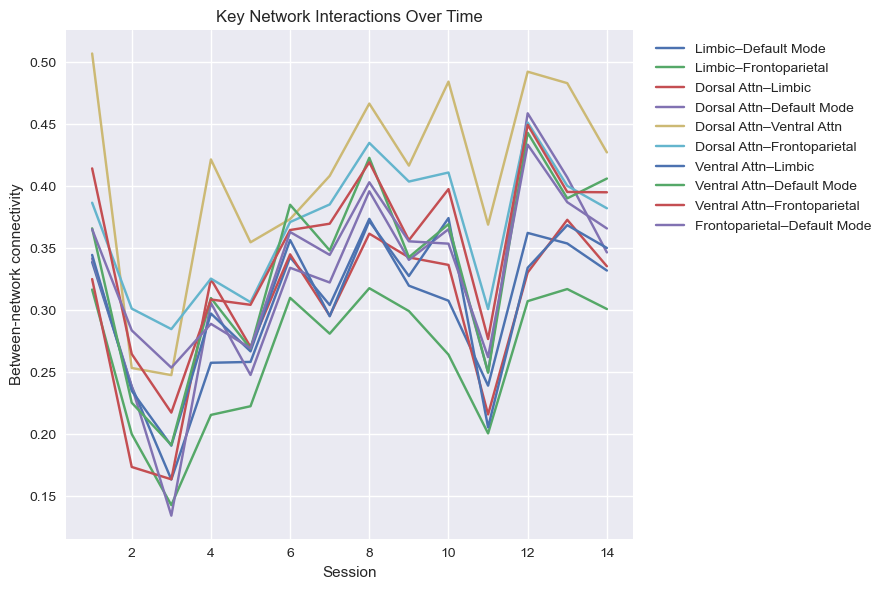

In [23]:
interesting = [4, 6, 2, 3, 5]  # Limbic, DMN, DorsalAttn, VentralAttn, Frontoparietal

plt.figure(figsize=(9,6))

for i in interesting:
    for j in interesting:
        if i < j:
            between = ALL[:, :, i, j]
            mean_traj = np.nanmean(between, axis=0)
            label = f"{network_names[i]}–{network_names[j]}"
            plt.plot(x, mean_traj, label=label)

plt.xlabel("Session")
plt.ylabel("Between-network connectivity")
plt.title("Key Network Interactions Over Time")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [24]:
bad = []
for i, subj in enumerate(subjs):
    for j, sess in enumerate(sessions_14):
        netmat = ALL[i, j]
        if np.isnan(netmat).all():
            bad.append((subj, sess, "ALL_NAN"))
        else:
            if np.isnan(np.diag(netmat)).all():
                bad.append((subj, sess, "DIAG_ALL_NAN"))
            tri = np.triu_indices(7, k=1)
            if np.isnan(netmat[tri]).all():
                bad.append((subj, sess, "BETWEEN_ALL_NAN"))

print("Number of problematic entries:", len(bad))
print(*bad[:20], sep="\n")  # show first 20


Number of problematic entries: 2
('002GNV', 'V03_200', 'ALL_NAN')
('003GNV', 'V02_200', 'ALL_NAN')


In [25]:
subjs = sorted(data_all.keys())

# sessions present for everyone (intersection)
common_sessions = sorted(
    set.intersection(*[set(data_all[s].keys()) for s in subjs])
)

# keep only _200 and only first 14 by session number
common_sessions_200 = sorted([s for s in common_sessions if s.endswith("_200")])
print("Common _200 sessions:", common_sessions_200)
print("Count:", len(common_sessions_200))


Common _200 sessions: ['V01_200', 'V04_200', 'V05_200', 'V06_200', 'V07_200', 'V08_200', 'V09_200', 'V10_200', 'V11_200', 'V12_200', 'V13_200', 'V14_200', 'V15_200']
Count: 13


In [26]:
sessions_use = common_sessions_200  # use all common ones
x = np.array([int(s[1:3]) for s in sessions_use])  # session numbers for plotting

ALL = np.full((len(subjs), len(sessions_use), 7, 7), np.nan)

for i, subj in enumerate(subjs):
    for j, sess in enumerate(sessions_use):
        ts = data_all[subj][sess]
        ALL[i, j] = compute_network_matrix(ts, yeo_rois, cortical_mask)

print("ALL shape:", ALL.shape)


ALL shape: (3, 13, 7, 7)


In [27]:
tri = np.triu_indices(7, k=1)
segregation = np.full((len(subjs), len(sessions_use)), np.nan)

for i in range(len(subjs)):
    for j in range(len(sessions_use)):
        netmat = ALL[i, j]
        within = np.nanmean(np.diag(netmat))
        between = np.nanmean(netmat[tri])
        segregation[i, j] = within - between


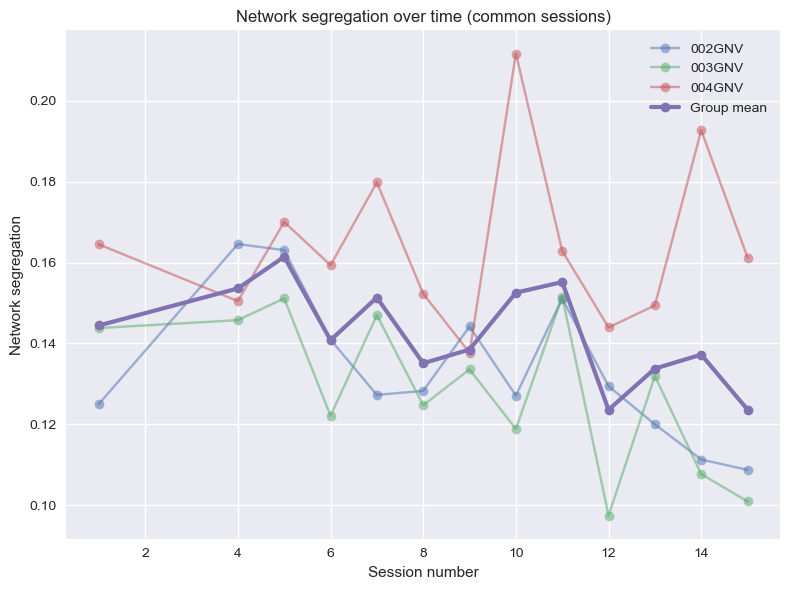

In [28]:
plt.figure(figsize=(8,6))

for i, subj in enumerate(subjs):
    plt.plot(x, segregation[i], marker="o", alpha=0.5, label=subj)

plt.plot(x, np.nanmean(segregation, axis=0), marker="o", linewidth=3, label="Group mean")

plt.xlabel("Session number")
plt.ylabel("Network segregation")
plt.title("Network segregation over time (common sessions)")
plt.legend()
plt.tight_layout()
plt.show()


In [29]:
import numpy as np

# --- Yeo labels (length 219) ---
yeo_info = rsfMRI_utils["yeo7"][200]
yeo_rois_all = np.array(yeo_info["yeoROIs"]).astype(int).ravel()

# cortical-only mask (exclude 8 & 9)
cortical_mask_all = yeo_rois_all <= 7
yeo_cx = yeo_rois_all[cortical_mask_all]  # length ~200, labels 1..7

def modularity_Q(A, communities):
    """
    Weighted modularity Q for an undirected network with nonnegative weights.
    A: (N,N) adjacency (weights), symmetric, diagonal = 0
    communities: length N array of community labels (e.g., 1..7)
    """
    A = np.asarray(A, dtype=float)

    # total weight (2m in Newman notation is sum of all weights)
    m2 = A.sum()
    if m2 <= 0 or np.isnan(m2):
        return np.nan

    k = A.sum(axis=1)  # node strengths

    # modularity sum over within-community pairs
    Q = 0.0
    for c in np.unique(communities):
        idx = np.where(communities == c)[0]
        if idx.size == 0:
            continue
        A_cc = A[np.ix_(idx, idx)].sum()
        k_cc = k[idx].sum()
        Q += (A_cc - (k_cc * k_cc) / m2)

    return Q / m2


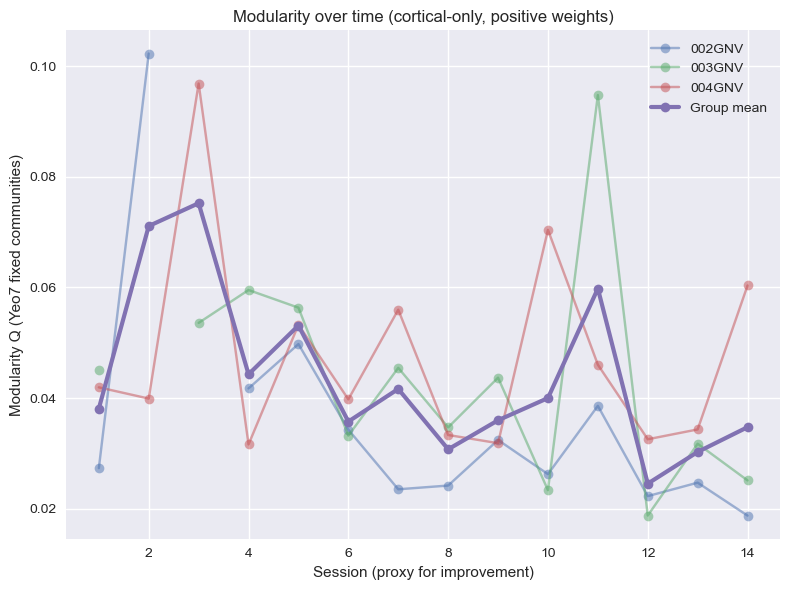

In [30]:
subjs = sorted(data_all.keys())
sessions_14 = [f"V{str(k).zfill(2)}_200" for k in range(1, 15)]
x = np.arange(1, 15)

Qmat = np.full((len(subjs), len(sessions_14)), np.nan)

for i, subj in enumerate(subjs):
    for j, sess in enumerate(sessions_14):
        if sess not in data_all[subj]:
            continue
        ts = data_all[subj][sess]
        fc = np.corrcoef(ts, rowvar=False)
        np.fill_diagonal(fc, 0)
        fc_cx = fc[np.ix_(cortical_mask_all, cortical_mask_all)]
        A = np.clip(fc_cx, 0, None)  # positive weights only
        Qmat[i, j] = modularity_Q(A, yeo_cx)


plt.figure(figsize=(8,6))
for i, subj in enumerate(subjs):
    plt.plot(x, Qmat[i], marker="o", alpha=0.5, label=subj)

plt.plot(x, np.nanmean(Qmat, axis=0), marker="o", linewidth=3, label="Group mean")
plt.xlabel("Session (proxy for improvement)")
plt.ylabel("Modularity Q (Yeo7 fixed communities)")
plt.title("Modularity over time (cortical-only, positive weights)")
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
def global_efficiency_weighted(fc_matrix):
    """
    Compute weighted global efficiency from a correlation matrix.
    Uses positive weights only.
    """
    # keep positive weights
    W = np.clip(fc_matrix, 0, None)
    
    # remove diagonal
    np.fill_diagonal(W, 0)
    
    # if all zeros, return NaN
    if np.sum(W) == 0:
        return np.nan
    
    # convert to distance matrix
    D = np.zeros_like(W)
    nonzero = W > 0
    D[nonzero] = 1.0 / W[nonzero]
    
    # build graph
    G = nx.from_numpy_array(D)
    
    # compute global efficiency manually
    N = len(G)
    path_length = dict(nx.all_pairs_dijkstra_path_length(G, weight='weight'))
    
    inv_dist_sum = 0
    count = 0
    
    for i in range(N):
        for j in range(N):
            if i != j:
                try:
                    inv_dist_sum += 1.0 / path_length[i][j]
                    count += 1
                except:
                    continue
    
    return inv_dist_sum / count


In [32]:
subjs = sorted(data_all.keys())
sessions_14 = [f"V{str(k).zfill(2)}_200" for k in range(1, 15)]
x = np.arange(1, 15)

GE = np.full((len(subjs), len(sessions_14)), np.nan)

for i, subj in enumerate(subjs):
    for j, sess in enumerate(sessions_14):
        if sess not in data_all[subj]:
            continue
        
        ts = data_all[subj][sess]
        fc = np.corrcoef(ts, rowvar=False)
        np.fill_diagonal(fc, 0)
        
        # cortical only
        fc_cx = fc[np.ix_(cortical_mask_all, cortical_mask_all)]
        
        GE[i, j] = global_efficiency_weighted(fc_cx)


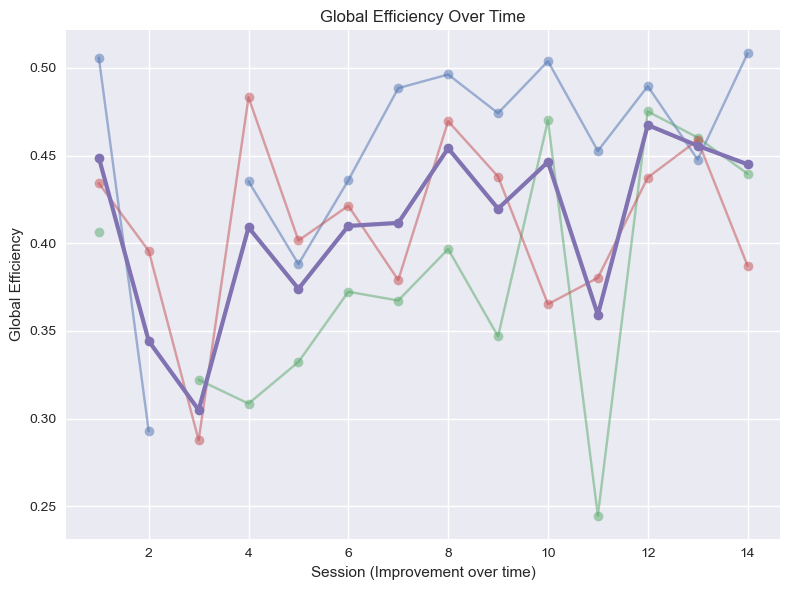

In [33]:
plt.figure(figsize=(8,6))

for i, subj in enumerate(subjs):
    plt.plot(x, GE[i], marker="o", alpha=0.5)

plt.plot(x, np.nanmean(GE, axis=0), marker="o", linewidth=3)

plt.xlabel("Session (Improvement over time)")
plt.ylabel("Global Efficiency")
plt.title("Global Efficiency Over Time")
plt.tight_layout()
plt.show()
